In [31]:
!pip install youtube-transcript-api
!pip install faiss

ERROR: Could not find a version that satisfies the requirement faiss (from versions: none)
ERROR: No matching distribution found for faiss


In [2]:
from langchain_openai import OpenAIEmbeddings
from dotenv import load_dotenv
from langchain_community.vectorstores import Chroma
from langchain_core.documents import Document
load_dotenv()

/mnt/d/Learning/Java/genAI/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


True

In [19]:
# Step 1a : Indexing (Document Ingestion)
from youtube_transcript_api import YouTubeTranscriptApi
video_id = "J5_-l7WIO_w"

ytt_api = YouTubeTranscriptApi()
transcript_obj = ytt_api.fetch(video_id, languages=['hi'])

In [21]:
transcript = " ".join([entry.text for entry in transcript_obj])
print(transcript[:10])

हाय गाइज़, 


In [24]:
# Step 1b: TextChunking
from langchain_text_splitters import RecursiveCharacterTextSplitter
text_splitter = RecursiveCharacterTextSplitter(chunk_size=1000,chunk_overlap=200)
chunks = text_splitter.create_documents([transcript])

In [26]:
print(len(chunks))
print(chunks[0])

51
page_content='हाय गाइज़, माय नेम इज नितेश एंड यू आर वेलकम टू माय YouTube चैनल। इस वीडियो में भी हम लोग अपना लैंग चेन प्लेलिस्ट कंटिन्यू करेंगे। अह पिछले वीडियो में हमने रैग पढ़ना शुरू किया था और हमने फोकस किया था रैग के अराउंड जो भी थ्योरी है उसको डिस्कस करने के ऊपर। मैंने आपको बताया था कि रैग क्या होता है? उसकी जरूरत क्यों होती है? मैंने वहां पर रैक को कंपेयर करके भी दिखाया था फाइन ट्यूनिंग जैसी टेक्निक के साथ। और आज का जो वीडियो है वह पिछले वीडियो का ही कंटिन्यूएशन है। जहां पर हम प्रैक्टिकली एक रैग बेस्ड सिस्टम बनाएंगे यूजिंग लैंग चेन। प्लान यह है कि मैं एक प्रॉब्लम स्टेटमेंट उठाऊंगा और उस प्रॉब्लम स्टेटमेंट के अराउंड एक रैग बेस्ड सिस्टम क्रिएट करूंगा और यह सारा का सारा कोड हम लैंग चेन में करने वाले हैं। तो अभी तक आपने जो भी पढ़ा है पिछले चारप वीडियोस में डॉक्यूमेंट लोडर्स, टेक्स्ट स्प्लिटर्स, वेक्टर स्टर्स ये सब कुछ हम आज के वीडियो में यूज़ करेंगे और इनको यूज़ करके हम एक रैग बेस सिस्टम बनाएंगे। ऑन द होल इट्स गोइंग टू बी अ वेरी इंटरेस्टिंग वीडियो। लेट्स स्टार्ट। तो चलो गाइस, सबसे पहले

# Step 1c and 1d (Embedding Generation and Store in Vector Stores)


In [27]:
from langchain_community.vectorstores import FAISS 

In [34]:
embeddings = OpenAIEmbeddings(model="text-embedding-3-small")
vectorstore = Chroma.from_documents(
    documents=chunks,
    embedding=embeddings,
    persist_directory="./rag_youtube"
)

# Step 2 : Retriver

In [39]:
retriever = vectorstore.as_retriever(
    search_type="mmr",
    search_kwargs={
        "k":4,
        "lambda_mult": 0.5     # Relevance-diversity balance
    }
)
retriever.invoke('What this video is about?')

[Document(metadata={}, page_content='हूं कि हमारा पूरा जो फ्लो रहेगा इस प्रोजेक्ट को बिल्ड करने का वो कैसा रहेगा। तो सबसे पहले आप क्या करोगे कि आप आपका जो YouTube वीडियो है जिससे आप चैट करना चाहते हो आप उसका ट्रांसक्रिप्ट लोड करोगे। ठीक है? सो ट्रांसक्रिप्ट एक फाइल होती है जहां पर YouTube वीडियो में जो भी बोला गया है वो सेंटेंस बाय सेंटेंस एक जगह पे रिकॉर्डेड रहता है। ठीक है? तो हमारा सबसे पहला गोल इज कि हम किसी तरीके से इस ट्रांसक्रिप्ट को फेच करके हमारे प्रोजेक्ट में लेके आए। अब ये जो काम है यह कई तरीकों से किया जा सकता है। एक तरीका यह है कि आप लैंगचेन में एक डॉक्यूमेंट लोडर है जिसको हम वाईटी लोडर बोलते हैं। YouTube लोडर उसको यूज़ करके लोड कर सकते हो। सेकंड ऑप्शन इज़ कि YouTube की खुद की भी कुछ एपीआई हैं जिनको आप डायरेक्टली हिट करके किसी भी वीडियो का ट्रांसक्रिप्ट लोड कर सकते हो। हमारे केस में हम YouTube की खुद की एपीआई यूज़ करेंगे। उसका रीज़न यह है कि मैं ट्राई तो कर रहा था लैंगचेन का YouTube लोडर यूज़ करने का बट यह थोड़ा सा बगी है। कुछ वीडियोस के केस में यह सही से काम कर रहा था। कुछ वीडि

# Step3 : Augmentation

In [42]:
from langchain_core.prompts import PromptTemplate
prompt_template = PromptTemplate(
    input_variables=["context", "question"],
    template="""
You are a helpful AI assistant.

Use the following context to answer the question.
If the answer is not in the context, say "I don't know."

Context:
{context}

Question:
{question}

Answer:
"""
)

In [45]:
question = "What is the main topic or idea discussed in the video?"
retrieved_docs = retriever.invoke(question)

In [46]:
context = "\n\n".join(doc.page_content for doc in retrieved_docs)

In [49]:
final_prompt = prompt_template.invoke({
    "context":context,
    "question":question
})

# Step 4: Generation

In [50]:
from langchain_openai import ChatOpenAI
llm = ChatOpenAI()
answer = llm.invoke(final_prompt)

In [52]:
print(answer.content)

The main topic or idea discussed in the video is about building a system to automatically generate transcripts from YouTube videos for projects.


# Using Chain
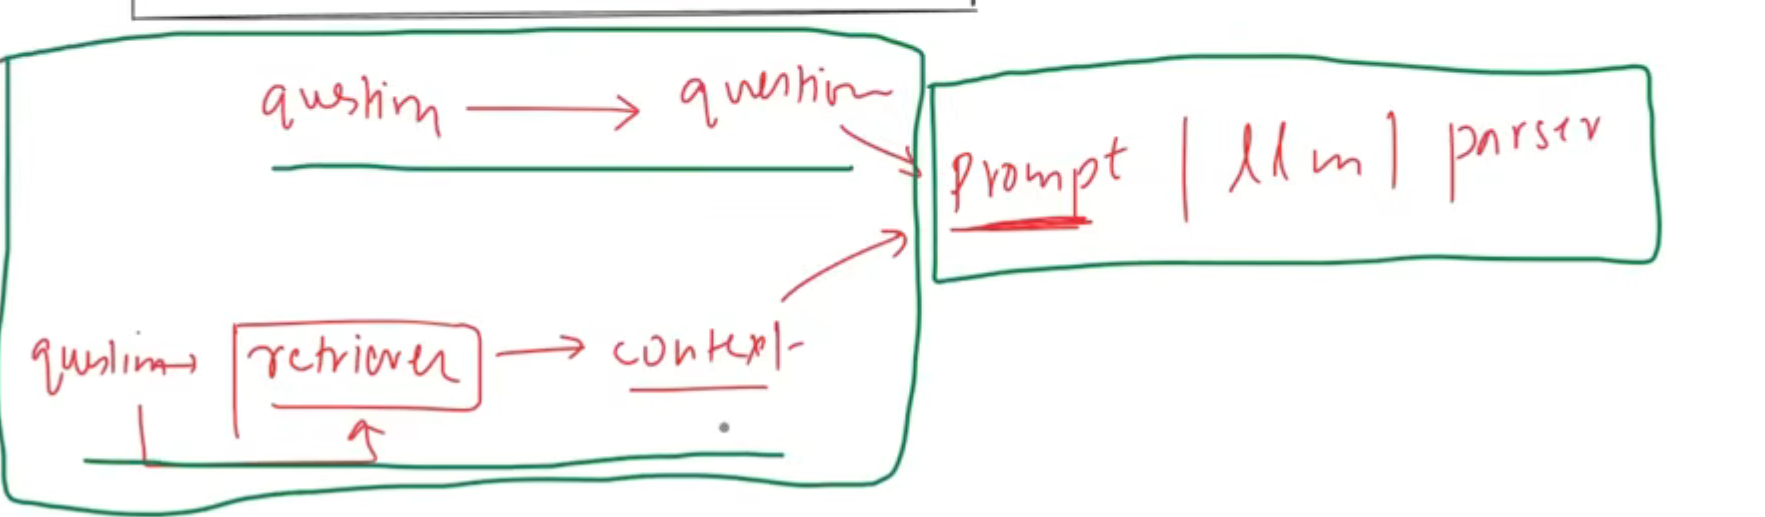

In [61]:
from langchain_core.runnables import RunnableParallel, RunnablePassthrough, RunnableLambda
from langchain_core.output_parsers import StrOutputParser

In [87]:
question = "Write steps to make Youtube Chatbot"
parser = StrOutputParser()

In [88]:
def format_docs(retrieved_docs):
    context_txt = "\n\n".join(doc.page_content for doc in retrieved_docs)
    return context_txt

In [89]:
parallel_chain = RunnableParallel({
    'question': RunnablePassthrough(),
    'context' : retriever | RunnableLambda(format_docs)
})

In [90]:
output = parallel_chain.invoke(
    question
)

In [91]:
print(output)

{'question': 'Write steps to make Youtube Chatbot', 'context': 'हूं कि हमारा पूरा जो फ्लो रहेगा इस प्रोजेक्ट को बिल्ड करने का वो कैसा रहेगा। तो सबसे पहले आप क्या करोगे कि आप आपका जो YouTube वीडियो है जिससे आप चैट करना चाहते हो आप उसका ट्रांसक्रिप्ट लोड करोगे। ठीक है? सो ट्रांसक्रिप्ट एक फाइल होती है जहां पर YouTube वीडियो में जो भी बोला गया है वो सेंटेंस बाय सेंटेंस एक जगह पे रिकॉर्डेड रहता है। ठीक है? तो हमारा सबसे पहला गोल इज कि हम किसी तरीके से इस ट्रांसक्रिप्ट को फेच करके हमारे प्रोजेक्ट में लेके आए। अब ये जो काम है यह कई तरीकों से किया जा सकता है। एक तरीका यह है कि आप लैंगचेन में एक डॉक्यूमेंट लोडर है जिसको हम वाईटी लोडर बोलते हैं। YouTube लोडर उसको यूज़ करके लोड कर सकते हो। सेकंड ऑप्शन इज़ कि YouTube की खुद की भी कुछ एपीआई हैं जिनको आप डायरेक्टली हिट करके किसी भी वीडियो का ट्रांसक्रिप्ट लोड कर सकते हो। हमारे केस में हम YouTube की खुद की एपीआई यूज़ करेंगे। उसका रीज़न यह है कि मैं ट्राई तो कर रहा था लैंगचेन का YouTube लोडर यूज़ करने का बट यह थोड़ा सा बगी है। कुछ वीडियोस के केस में यह सही

In [92]:
generation_chain = prompt_template | llm | parser
generation_chain.invoke(output)

'1. Load the transcript of your YouTube video into the project.\n2. Fetch the transcript using a YouTube loader or directly hit the YouTube API.\n3. Utilize HTML, CSS, and JavaScript knowledge to create a Chrome plugin.\n4. Install the Chrome plugin to allow users to chat while watching videos.\n5. Alternatively, create a streamlined website where users can paste the link to a YouTube video to chat.'

In [94]:
final_chain = parallel_chain | generation_chain 
result = final_chain.invoke(question)
print(result)

To make a Youtube Chatbot, you can follow these steps:

1. Load the transcript of the YouTube video you want to chat about.
2. Extract the text sentences from the transcript and record them line by line.
3. Fetch the transcript into your project using a document loader or YouTube API.
4. Create a chat system interface where users can interact while watching the video.
5. Implement functionality for users to ask questions and interact with the chatbot.
6. Use HTML, CSS, and JavaScript knowledge to develop the chatbot interface.
7. Optionally, consider creating a Chrome plugin where users can install the chatbot for easier access while watching YouTube videos.
8. Test the chatbot system for functionality and user experience.
9. Iterate on the design and features based on feedback from users.
10. Launch the Youtube Chatbot for public use and continue to improve it based on user interactions and feedback.
